In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/Unemployment in India.csv")

In [3]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [6]:
df.columns = df.columns.str.strip()

In [7]:
df.duplicated().sum()

np.int64(27)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()/len(df)

,0
Region,0.00135
Date,0.00135
Frequency,0.00135
Estimated Unemployment Rate (%),0.00135
Estimated Employed,0.00135
Estimated Labour Participation Rate (%),0.00135
Area,0.00135


In [11]:
df.dropna(inplace=True)

In [12]:
df["Date"] = pd.to_datetime(df['Date'],dayfirst=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


In [14]:
df['Date'].value_counts()

,count
Date,
2019-10-31,55
2019-11-30,55
2019-06-30,54
2019-07-31,54
2019-05-31,54
2019-08-31,53
2020-01-31,53
2019-12-31,53
2020-02-29,53


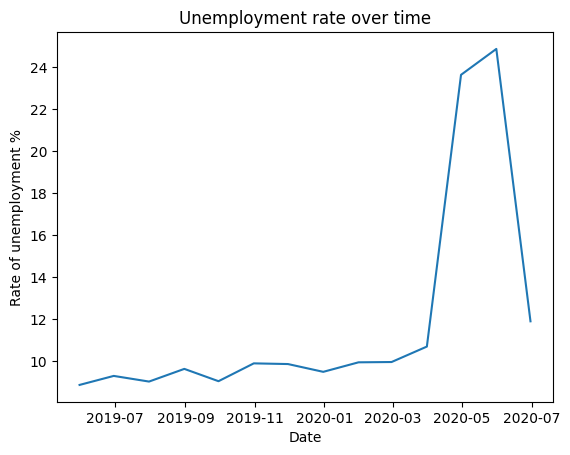

In [15]:
unemp_by_date = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

sns.lineplot(unemp_by_date)
plt.xlabel('Date')
plt.ylabel('Rate of unemployment %')
plt.title('Unemployment rate over time')
plt.show()

# There was a big increase in unemployment from April 2020 to July 2020 because of covid-19.

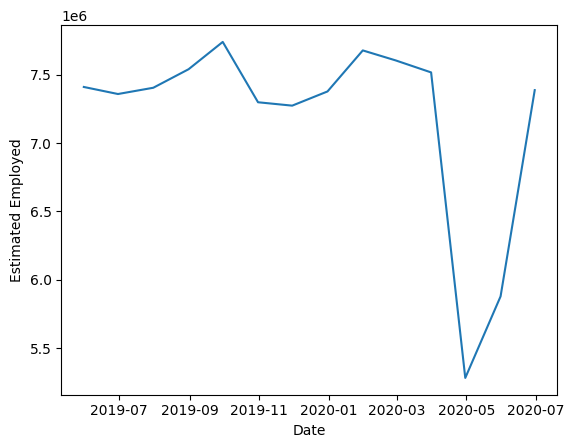

In [16]:
employed_by_date = df.groupby('Date')['Estimated Employed'].mean()

sns.lineplot(employed_by_date)
plt.show()

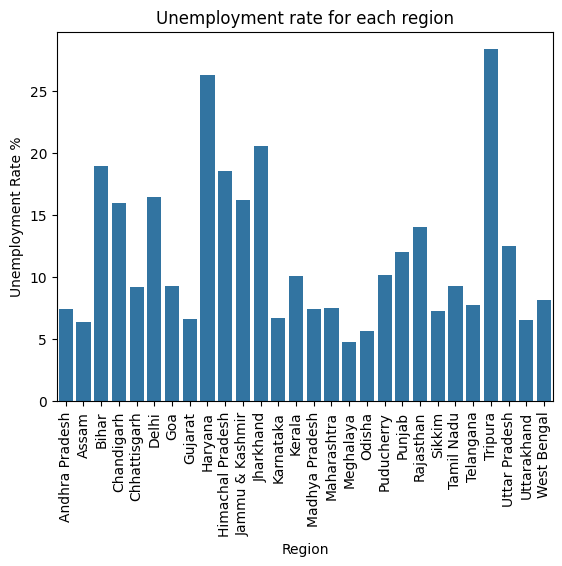

In [22]:
unemp_by_region = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

sns.barplot(unemp_by_region)
plt.xlabel('Region')
plt.ylabel('Unemployment Rate %')
plt.title('Unemployment rate for each region')
plt.xticks(rotation=90)
plt.show()



Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Name: Estimated Unemployment Rate (%), dtype: float64


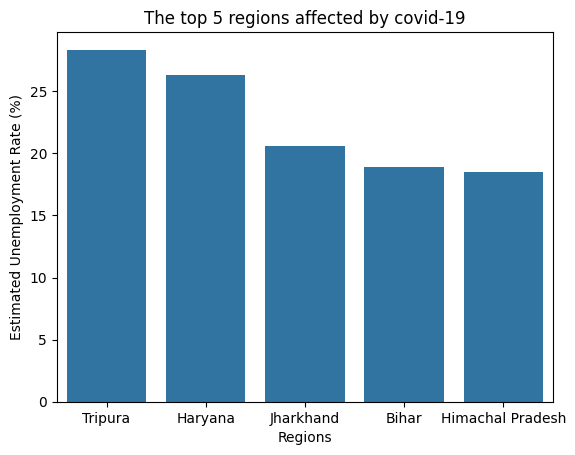

In [18]:
top5 = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)
print(top5)

sns.barplot(top5)
plt.xlabel('Regions')
plt.title("The top 5 regions affected by covid-19")
plt.show()

# There are some regions where the unemployment rate exceeded 20%, and they are: Tripura, Haryana,Jharkhand, Bihar and Himachal Pradesh

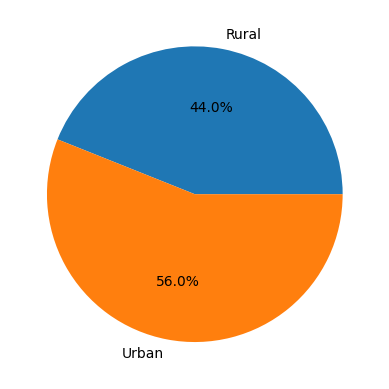

In [19]:
unemp_by_area = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

plt.pie(
    unemp_by_area,
    labels=unemp_by_area.index,
    autopct='%1.1f%%'
)
plt.show()
# Urban is affected by covid-19 mare than rural

In [20]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


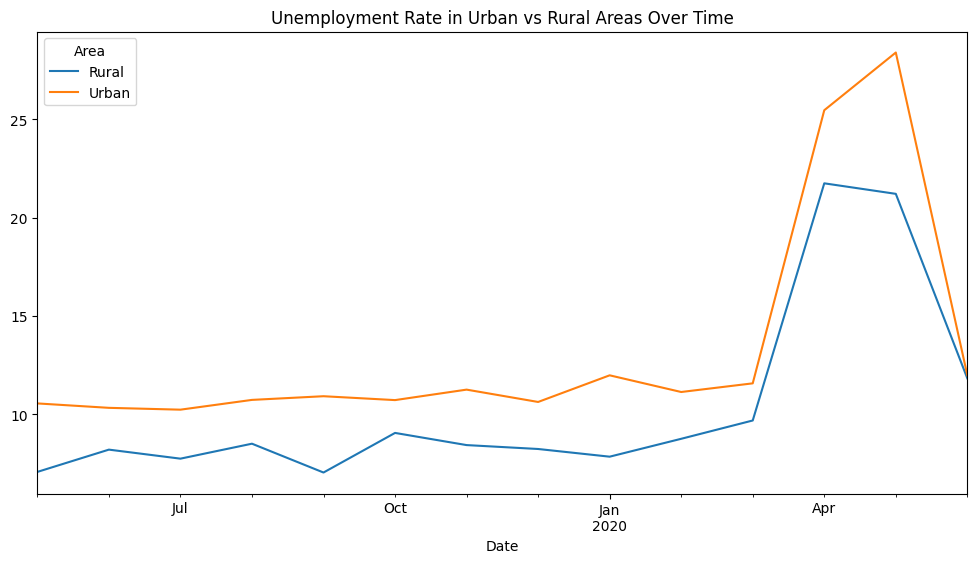

In [21]:
area_time = df.groupby([df['Date'].dt.to_period('M'), 'Area'])['Estimated Unemployment Rate (%)'].mean().unstack()
area_time.plot(figsize=(12,6))
plt.title('Unemployment Rate in Urban vs Rural Areas Over Time')
plt.show()

In [26]:

pre_covid = df[df['Date'] < '2020-03-01']['Estimated Unemployment Rate (%)'].mean()
post_covid = df[df['Date'] >= '2020-03-01']['Estimated Unemployment Rate (%)'].mean()
print(f"Average unemployment rate before COVID-19: {pre_covid:.2f}%")
print(f"Average unemployment rate after COVID-19: {post_covid:.2f}%")
print(f"The percentage increase was: {(post_covid/pre_covid - 1)*100:.1f}%")

Average unemployment rate before COVID-19: 9.51%
Average unemployment rate after COVID-19: 17.77%
The percentage increase was: 86.9%
